In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving exercise1_house_purchase.csv to exercise1_house_purchase.csv


In [ ]:
import os

print(os.listdir())

['.config', 'exercise1_house_purchase.csv', 'Decision_Tree_Exercises_7_6.zip', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("exercise1_house_purchase.csv")

df.head()

,Age,Income,Gender,Marital_Status,Buys_House
0,25,50000,Male,Single,Yes
1,35,75000,Female,Married,No
2,28,60000,Male,Single,Yes
3,45,90000,Female,Married,Yes
4,30,80000,Male,Married,No


In [ ]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset:")
display(df)

Dataset shape: (12, 5)

Columns:
['Age', 'Income', 'Gender', 'Marital_Status', 'Buys_House']

Dataset:


,Age,Income,Gender,Marital_Status,Buys_House
0,25,50000,Male,Single,Yes
1,35,75000,Female,Married,No
2,28,60000,Male,Single,Yes
3,45,90000,Female,Married,Yes
4,30,80000,Male,Married,No
5,22,45000,Female,Single,Yes
6,40,85000,Male,Married,No
7,32,70000,Female,Single,Yes
8,38,95000,Male,Married,Yes
9,27,55000,Female,Married,No


In [ ]:
X = df[["Age", "Income"]]
y = df["Buys_House"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Predicted:", y_pred)
print("Actual:", y_test.values)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Predicted: ['No' 'Yes' 'Yes']
Actual: ['Yes' 'No' 'Yes']

Accuracy:
0.3333333333333333

Classification Report:
              precision    recall  f1-score   support

          No       0.00      0.00      0.00         1
         Yes       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



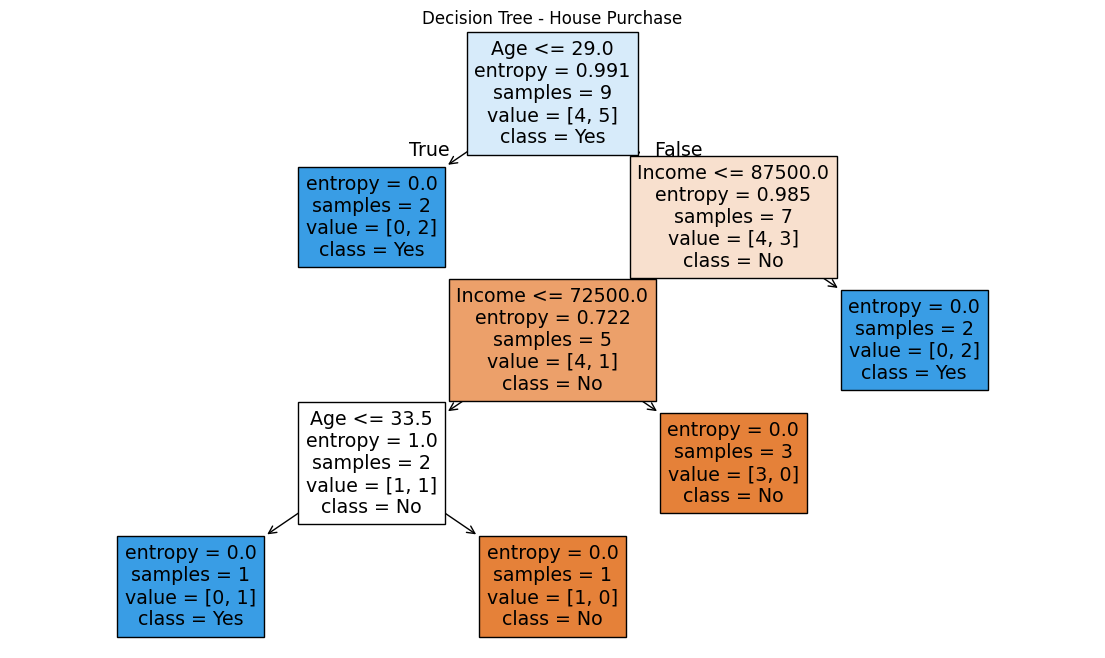

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))

plot_tree(
    model,
    feature_names=["Age", "Income"],
    class_names=model.classes_,
    filled=True
)

plt.title("Decision Tree - House Purchase")
plt.show()

In [ ]:
from google.colab import files

uploaded_weather = files.upload()

Saving exercise2_weather.csv to exercise2_weather.csv


In [ ]:
weather_df = pd.read_csv(next(iter(uploaded_weather)))

display(weather_df)

print("Columns:")
print(weather_df.columns.tolist())

,Day,Outlook,Temperature,Humidity,Wind,Play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


Columns:
['Day', 'Outlook', 'Temperature', 'Humidity', 'Wind', 'Play']


In [ ]:
from sklearn.preprocessing import LabelEncoder

X_weather = weather_df[
    ["Outlook", "Temperature", "Humidity", "Wind"]
].copy()

y_weather = weather_df["Play"]

encoders = {}

for column in X_weather.columns:
    encoder = LabelEncoder()

    X_weather[column] = encoder.fit_transform(
        X_weather[column]
    )

    encoders[column] = encoder

target_encoder = LabelEncoder()

y_weather = target_encoder.fit_transform(y_weather)

print(X_weather.head())
print(y_weather)

   Outlook  Temperature  Humidity  Wind
0        2            1         0     1
1        2            1         0     0
2        0            1         0     1
3        1            2         0     1
4        1            0         1     1
[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_weather,
    y_weather,
    test_size=0.20,
    random_state=42
)

In [ ]:
weather_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

weather_model.fit(
    X_train,
    y_train
)

print("Weather Decision Tree trained successfully.")

Weather Decision Tree trained successfully.


In [ ]:
y_pred = weather_model.predict(X_test)

print("Predicted:", y_pred)
print("Actual:", y_test)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)

Predicted: [1 1 0]
Actual: [1 1 0]

Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



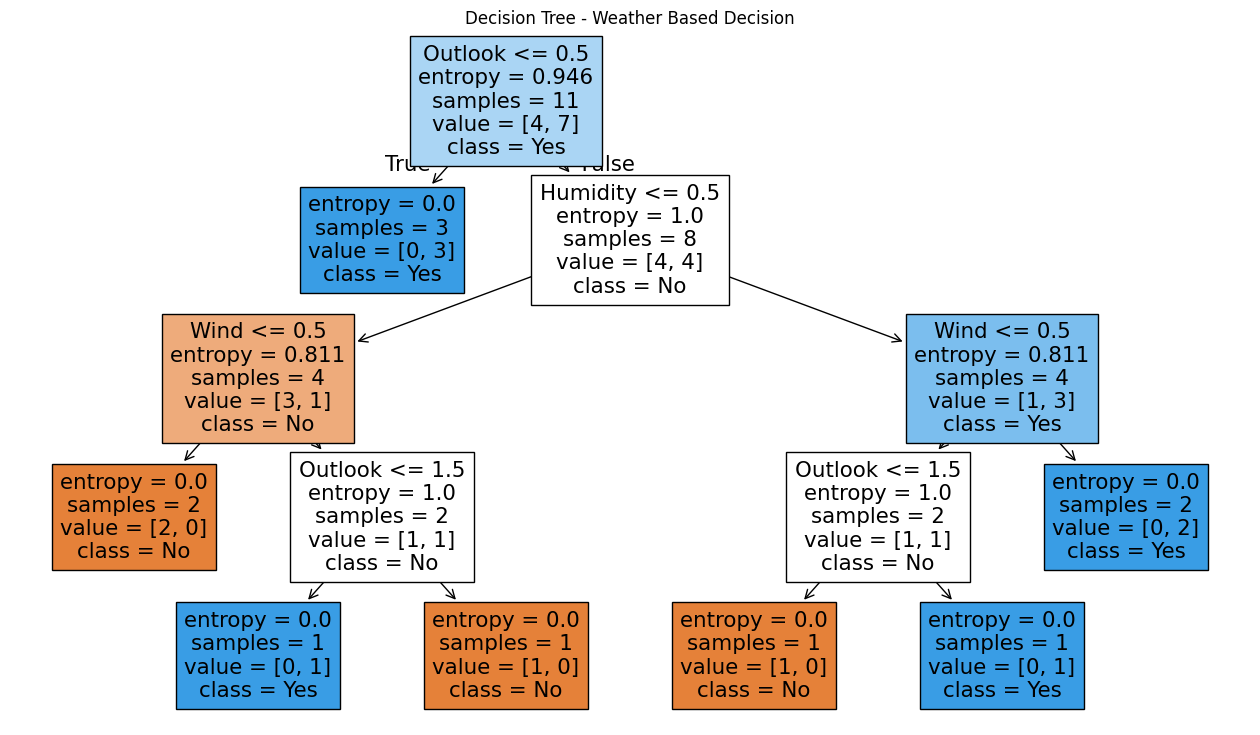

In [ ]:
plt.figure(figsize=(16, 9))

plot_tree(
    weather_model,
    feature_names=X_weather.columns,
    class_names=target_encoder.classes_,
    filled=True
)

plt.title("Decision Tree - Weather Based Decision")

plt.show()